In [15]:
import pandas as pd
import numpy as np
from scipy import stats
import os

In [16]:
LOUVAIN_PERFOLD = "louvain_cv_results_norm_per_fold.csv"
LOUVAIN_SUMMARY = "louvain_cv_results_norm_summary.csv"

LPA_PERFOLD = "lpa_cv_results_norm_per_fold.csv"
LPA_SUMMARY = "lpa_cv_results_norm_summary.csv"

SSLPA_PERFOLD = "sslpa_cv_results_per_fold.csv"
SSLPA_SUMMARY = "sslpa_cv_results_summary.csv"

In [17]:
OUTPUT_DIR = 'res'

In [18]:
louvain_perfold = pd.read_csv(LOUVAIN_PERFOLD)
lpa_perfold = pd.read_csv(LPA_PERFOLD)
sslpa_perfold = pd.read_csv(SSLPA_PERFOLD)


In [19]:
def create_comparison_table(louvain_df, lpa_df, sslpa_df):

    
    metrics = ['NMI', 'ARI', 'AMI', 'FMI', 'Homogeneity', 'Completeness', 'V-measure', 'Purity']
    
    results = []
    
    for metric in metrics:
        test_col = f'{metric}_test'
        

        louvain_mean = louvain_df[test_col].mean()
        louvain_std = louvain_df[test_col].std()
        
        lpa_mean = lpa_df[test_col].mean()
        lpa_std = lpa_df[test_col].std()
        
        sslpa_mean = sslpa_df[test_col].mean()
        sslpa_std = sslpa_df[test_col].std()
        
        results.append({
            'Metric': metric,
            'Louvain': f"{louvain_mean:.4f} ± {louvain_std:.4f}",
            'LPA': f"{lpa_mean:.4f} ± {lpa_std:.4f}",
            'SSLPA': f"{sslpa_mean:.4f} ± {sslpa_std:.4f}",
            'Louvain_mean': louvain_mean,
            'LPA_mean': lpa_mean,
            'SSLPA_mean': sslpa_mean,
        })
    
    return pd.DataFrame(results)


comparison_df = create_comparison_table(louvain_perfold, lpa_perfold, sslpa_perfold)


print("METHOD COMPARISON - TEST SET PERFORMANCE")

print(comparison_df[['Metric', 'Louvain', 'LPA', 'SSLPA']].to_string(index=False))




METHOD COMPARISON - TEST SET PERFORMANCE
      Metric         Louvain              LPA           SSLPA
         NMI 0.1314 ± 0.0058  0.1217 ± 0.0038 0.1284 ± 0.0223
         ARI 0.0459 ± 0.0066 -0.0009 ± 0.0028 0.0646 ± 0.0355
         AMI 0.0875 ± 0.0077  0.0555 ± 0.0040 0.0857 ± 0.0259
         FMI 0.6796 ± 0.0110  0.3579 ± 0.0118 0.7061 ± 0.0903
 Homogeneity 0.1819 ± 0.0070  0.3798 ± 0.0119 0.1744 ± 0.0396
Completeness 0.1029 ± 0.0051  0.0724 ± 0.0023 0.1078 ± 0.0364
   V-measure 0.1314 ± 0.0058  0.1217 ± 0.0038 0.1284 ± 0.0223
      Purity 0.9353 ± 0.0005  0.9401 ± 0.0009 0.9353 ± 0.0008


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Summary DataFrame:
    method  Avg_NMI_test  Avg_ARI_test  Avg_Purity_test
0  Louvain      0.131397      0.045947         0.935341
1      LPA      0.121650     -0.000911         0.940139
2    SSLPA      0.128434      0.064586         0.935341


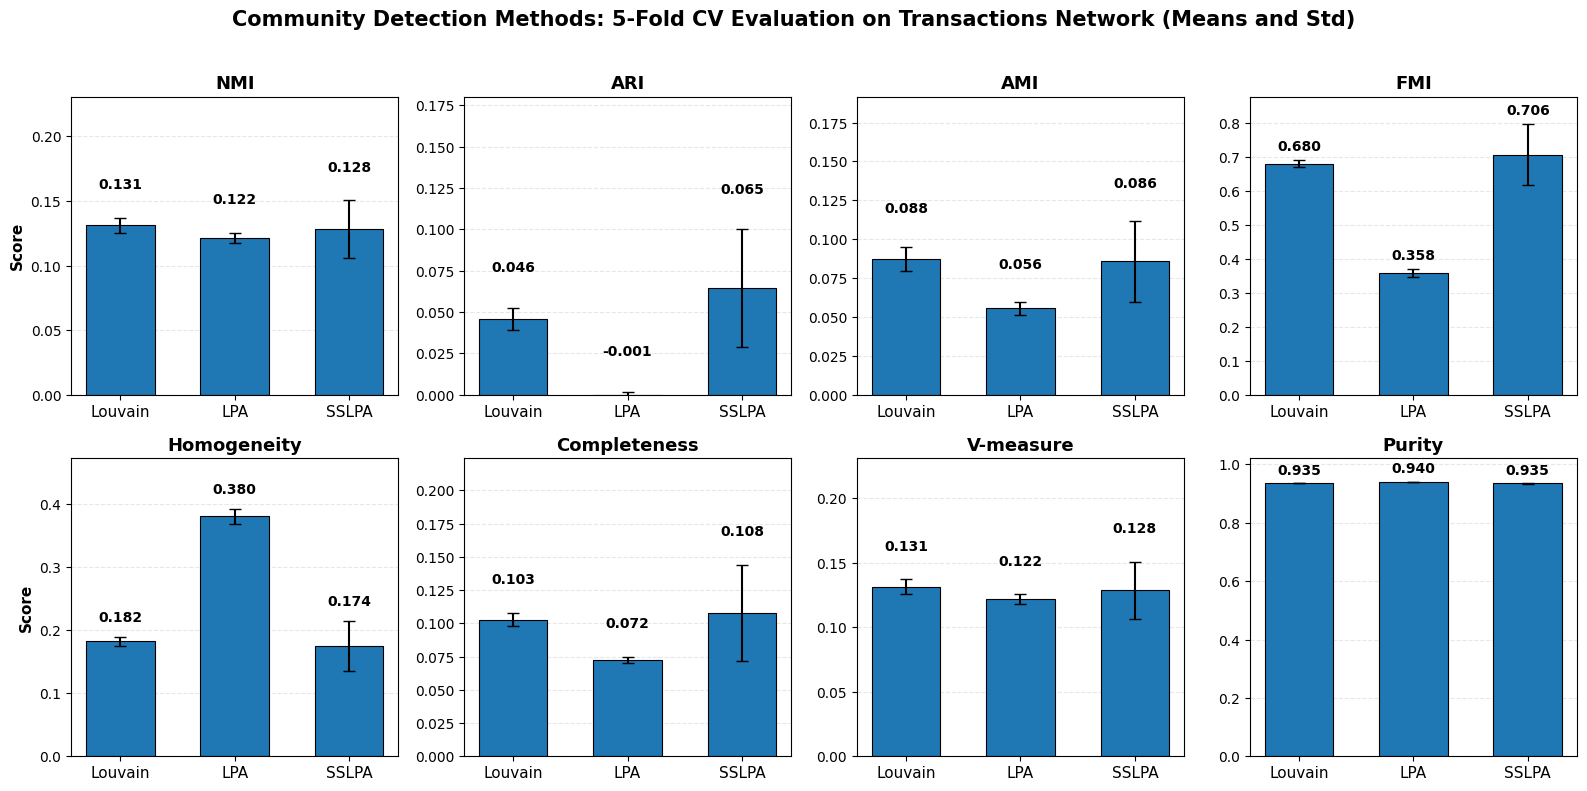

In [21]:


METHOD_ORDER = ["Louvain", "LPA", "SSLPA"]
ALL_METRICS = [
    ("Avg_NMI_test", "Std_NMI_test", "NMI"),
    ("Avg_ARI_test", "Std_ARI_test", "ARI"),
    ("Avg_AMI_test", "Std_AMI_test", "AMI"),
    ("Avg_FMI_test", "Std_FMI_test", "FMI"),
    ("Avg_Homogeneity_test", "Std_Homogeneity_test", "Homogeneity"),
    ("Avg_Completeness_test", "Std_Completeness_test", "Completeness"),
    ("Avg_V-measure_test", "Std_V-measure_test", "V-measure"),
    ("Avg_Purity_test", "Std_Purity_test", "Purity"),
]
COLOR_TX = "#1f77b4" 
ROUND_TO = 3

def create_summary_df(louvain_df, lpa_df, sslpa_df):
    
    metrics = ['NMI', 'ARI', 'AMI', 'FMI', 'Homogeneity', 'Completeness', 'V-measure', 'Purity']
    
    results = []
    
    for method_name, df in [('Louvain', louvain_df), ('LPA', lpa_df), ('SSLPA', sslpa_df)]:
        row = {'method': method_name, 'network': 'TX'}
        
        for metric in metrics:
            test_col = f'{metric}_test'
            row[f'Avg_{metric}_test'] = df[test_col].mean()
            row[f'Std_{metric}_test'] = df[test_col].std()
        
        results.append(row)
    
    return pd.DataFrame(results)

summary_df = create_summary_df(louvain_perfold, lpa_perfold, sslpa_perfold)

summary_df["method"] = pd.Categorical(summary_df["method"], METHOD_ORDER, ordered=True)
summary_df = summary_df.sort_values("method").reset_index(drop=True)

print("Summary DataFrame:")
print(summary_df[['method', 'Avg_NMI_test', 'Avg_ARI_test', 'Avg_Purity_test']])


plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

bar_width = 0.6
x = np.arange(len(METHOD_ORDER))

for i, (mean_col, std_col, label) in enumerate(ALL_METRICS):
    ax = axes[i]
    
    means = [float(summary_df.loc[summary_df["method"] == m, mean_col].values[0]) for m in METHOD_ORDER]
    stds = [float(summary_df.loc[summary_df["method"] == m, std_col].values[0]) for m in METHOD_ORDER]
    
    ymax = max(np.array(means) + np.array(stds))
    
    bars = ax.bar(
        x,
        means,
        yerr=stds,
        width=bar_width,
        color=COLOR_TX,
        edgecolor="black",
        linewidth=0.8,
        capsize=4,
        error_kw={'elinewidth': 1.5}
    )
    
    for bar, val, sd in zip(bars, means, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + sd + 0.02,
            f"{val:.{ROUND_TO}f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight='bold'
        )
    
    ax.set_title(label, fontweight='bold', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(METHOD_ORDER, fontsize=11)

    upper = min(1.08, ymax + 0.08)
    ax.set_ylim(0, upper)
    ax.grid(alpha=0.3, axis="y", linestyle='--')
    ax.set_axisbelow(True)
    

    if i in [0, 4]:
        ax.set_ylabel("Score", fontweight='bold', fontsize=11)

# Title
fig.suptitle(
    "Community Detection Methods: 5-Fold CV Evaluation on Transactions Network (Means and Std)",
    y=0.995,
    fontsize=15,
    fontweight='bold'
)

fig.tight_layout(rect=[0, 0.01, 1, 0.98])





plt.show()

